# Player Elo ratings from real match data

Turn the raw `data_test.xlsx` match file into a per-player Elo time series and export it.

Ratings implement Wolf, Schmitt & Schuller (2020), formulas (6)-(10): a team's strength is the
minutes-weighted mean of its line-up, and each player is nudged by their personal goal
difference vs. the Elo-expected result. Ratings follow the **person** across teams/seasons.

Output: one row per appearance — `Player, season, round, team_at, rating` (rating = **after** the match).

## 1. Setup

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while not (root / "data_test.xlsx").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import pandas as pd
import matplotlib.pyplot as plt
from dfg_rating.model import factory
from dfg_rating.model.network.base_network import WhiteNetwork
from dfg_rating.model.rating.player_elo_rating import PlayerELORating

## 2

In [ ]:
# Score from *_x columns; round = chronological match index per season; line-ups parsed as lists.
df = pd.read_excel("../../data/real/data_test.xlsx").rename(
    columns={"home_score_x": "home_score", "away_score_x": "away_score"})
df = df.sort_values(["season_id", "date"]).reset_index(drop=True)
df["round"] = df.groupby("season_id").cumcount() + 1

net = WhiteNetwork(data=df, mapping=factory.pre_mappings["player-soccer-lists"])
print(f"{len(df)} matches | {df['season_id'].nunique()} season | {len(net.players)} players")

## 3. Compute ratings
One chronological pass (defaults `k=32`, `q=0.75`, new players start at 1000).

In [3]:
net.add_player_rating(PlayerELORating(k=32, q=0.75, initial_rating=1000))

## 4. Export

In [ ]:
out = net.export_player_match_ratings(filename=str("player_ratings.csv"))
out.head()

## 5. FC Barcelona
Latest ratings of Barça's most-used players.

In [5]:
barca = out[out.team_at == "FC Barcelona"]
(barca.sort_values("round").groupby("Player")
      .agg(apps=("rating", "size"), rating=("rating", "last"))
      .sort_values("rating", ascending=False).head(10))

,apps,rating
Player,,
ter Stegen M.-A.,34,1212.684427
Lewandowski R.,44,1210.162626
Gündoğan İ.,45,1207.719768
Kounde J.,44,1201.201069
Araújo R.,32,1174.970370
João Félix,38,1165.146439
Yamal L.,37,1164.071891
Cancelo J.,40,1154.587309
López F.,31,1147.703291


## 6. Explore a player
First find the exact name with a regex search, then set `PLAYER` and run the chart.

In [6]:
SEARCH = "lewand"  # <-- case-insensitive regex; e.g. "^messi", "yamal", "de jong"

names = pd.Series(sorted(out.Player.unique()))
hits = names[names.str.contains(SEARCH, case=False, regex=True, na=False)]
print(f"{len(hits)} match(es) for {SEARCH!r}:")
list(hits)

1 match(es) for 'lewand':


['Lewandowski R.']

,season,round,team_at,rating,date
0,14,338,FC Barcelona,1000.061832,2023-08-13 21:30:00
1,14,560,FC Barcelona,1021.063998,2023-08-20 19:30:00
2,14,770,FC Barcelona,1036.329269,2023-08-27 17:30:00
3,14,1044,FC Barcelona,1051.078319,2023-09-03 21:00:00
4,14,1218,FC Barcelona,1075.143038,2023-09-16 21:00:00
5,14,1315,FC Barcelona,1099.344265,2023-09-19 21:00:00
6,14,1440,FC Barcelona,1110.165364,2023-09-23 18:30:00
7,14,1564,FC Barcelona,1117.867934,2023-09-26 21:30:00
8,14,1645,FC Barcelona,1129.176267,2023-09-29 21:00:00
9,14,1882,FC Barcelona,1129.212833,2023-10-04 21:00:00


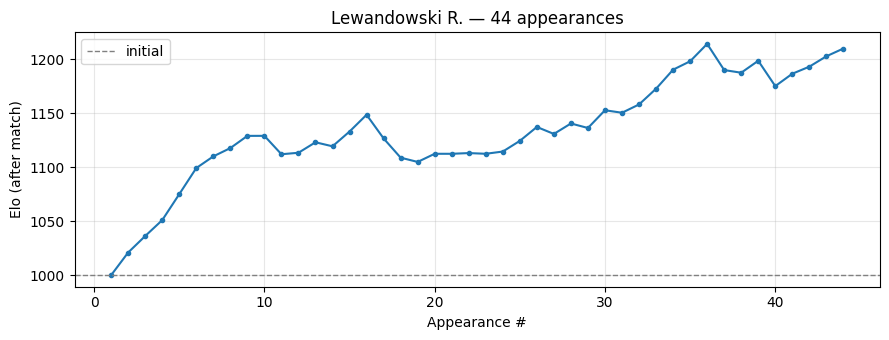

In [7]:
PLAYER = "Lewandowski R."  # <-- enter any player name

sub = out[out.Player == PLAYER].sort_values(["season", "round"]).reset_index(drop=True)
if sub.empty:
    print(f"No appearances for {PLAYER!r}. Examples:", sorted(out.Player.sample(5)))
else:
    display(sub[["season", "round", "team_at", "rating", "date"]])
    plt.figure(figsize=(9, 3.5))
    plt.plot(range(1, len(sub) + 1), sub["rating"], marker="o", ms=3)
    plt.axhline(1000, color="grey", ls="--", lw=1, label="initial")
    plt.xlabel("Appearance #"); plt.ylabel("Elo (after match)")
    plt.title(f"{PLAYER} — {len(sub)} appearances")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()